# Mortality-Anchored Reconstruction of Epidemic Incidence
**Epidemiological Archaeology of SARS-CoV-2 via $H^3$ Topological Regularization**

This notebook contains the complete analytical pipeline to reproduce the findings submitted to *The Lancet*. It processes global mortality and official case data to estimate the true latent incidence of COVID-19 across different waves and variants.

**Key Methodology:**
1. **Data Ingestion:** World Mortality Dataset (WMD) and JHU CSSE.
2. **Topological Regularization:** $L_1$ Total Variation penalty in the $H^3$ Sobolev space to preserve structural transmission breaks.
3. **Kinematic Deconvolution:** Back-calculation using a 20-day infection-to-death delay ($\tau$).
4. **Dynamic IFR:** Age-weighted Infection Fatality Ratio adjusted for Wild Type, Alpha/Delta/Vaccines, and Omicron eras.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.signal import find_peaks
from scipy.sparse import diags, eye
from scipy.sparse.linalg import spsolve
from datetime import timedelta
import matplotlib.dates as mdates
import os
import gc
import geopandas as gpd
import warnings

warnings.filterwarnings('ignore')

# Create output directory for paper figures
OUTPUT_DIR = "Archaeology_Global_Results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
# =============================================================================
# 1. DOWNLOAD DATA 
# =============================================================================
print("Downloading Global Datasets (Please wait a few seconds)...")
url_wmd = "https://raw.githubusercontent.com/akarlinsky/world_mortality/main/world_mortality.csv"
url_jhu_cases = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
url_jhu_deaths = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv"
url_jhu_pop = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/UID_ISO_FIPS_LookUp_Table.csv"

df_wmd_full = pd.read_csv(url_wmd)
df_jhu_cases_full = pd.read_csv(url_jhu_cases)
df_jhu_deaths_full = pd.read_csv(url_jhu_deaths)
df_pop_full = pd.read_csv(url_jhu_pop)

# =============================================================================
# 2. ALGORITHM PARAMETERS (Lancet Methodology)
# =============================================================================
TAU_SHIFT = 20             
LAMBDA_H3 = 5000           
START_DATE = pd.to_datetime('2020-02-01')
END_DATE = pd.to_datetime('2023-01-01')

# Dynamic IFR Eras
ERA_1_END = pd.to_datetime('2021-01-01')  
ERA_2_END = pd.to_datetime('2021-12-01')  

# Piecewise dynamic IFR values (IFR(t))
IFR_WILD_TYPE = 0.0105     
IFR_VACCINES  = 0.0060     
IFR_OMICRON   = 0.0010     

NAME_MAPPING = {
    "United States": "US", "South Korea": "Korea, South",
    "Taiwan": "Taiwan*", "Russia": "Russia"
}

# Standard aesthetics for publication
S_c_off_inf, S_c_lat_inf, S_c_fill_inf = '#85C1E9', '#154360', '#D4E6F1' 
S_c_off_dead, S_c_lat_dead, S_c_fill_dead = '#F1948A', '#C0392B', '#F5B7B1'

In [3]:
# =============================================================================
# 3. CORE PROCESSING FUNCTION (Mathematical Motor)
# =============================================================================
def process_country(wmd_country):
    jhu_country = NAME_MAPPING.get(wmd_country, wmd_country)
    
    pop_series = df_pop_full[df_pop_full['Country_Region'] == jhu_country]['Population'].dropna()
    if pop_series.empty or pop_series.sum() == 0: return None
    pop = pop_series.sum()

    df_cases_country = df_jhu_cases_full[df_jhu_cases_full['Country/Region'] == jhu_country].iloc[:, 4:].sum()
    if df_cases_country.empty: return None
    df_cases_country.index = pd.to_datetime(df_cases_country.index, format='%m/%d/%y')
    daily_cases_official = df_cases_country.diff().fillna(0).clip(lower=0)

    df_deaths_country = df_jhu_deaths_full[df_jhu_deaths_full['Country/Region'] == jhu_country].iloc[:, 4:].sum()
    df_deaths_country.index = pd.to_datetime(df_deaths_country.index, format='%m/%d/%y')
    daily_deaths_official = df_deaths_country.diff().fillna(0).clip(lower=0)

    df_wmd_c = df_wmd_full[df_wmd_full['country_name'] == wmd_country].copy()
    df_base = df_wmd_c[df_wmd_c['year'] < 2020]
    if df_base.empty: return None
    baseline = df_base.groupby('time')['deaths'].mean().to_dict()
    
    df_pand = df_wmd_c[df_wmd_c['year'] >= 2020].copy()
    df_pand['baseline'] = df_pand['time'].map(baseline)
    df_pand['excess'] = df_pand['deaths'] - df_pand['baseline']

    if df_pand['time_unit'].iloc[0] == 'weekly':
        df_pand['Date'] = pd.to_datetime(df_pand['year'].astype(str) + df_pand['time'].astype(str) + '1', format='%G%V%u')
        divider = 7.0
    else: 
        df_pand['Date'] = pd.to_datetime(df_pand['year'].astype(str) + '-' + df_pand['time'].astype(str) + '-01')
        divider = 30.0

    df_pand = df_pand.sort_values('Date').dropna(subset=['Date', 'excess'])
    if df_pand.empty: return None
    
    numeric_days = (df_pand['Date'] - df_pand['Date'].min()).dt.days
    cs = CubicSpline(numeric_days, df_pand['excess'])
    daily_dates = pd.date_range(start=df_pand['Date'].min(), end=df_pand['Date'].max(), freq='D')
    eval_days = (daily_dates - df_pand['Date'].min()).days
    raw_daily_deaths = cs(eval_days) / divider

    n = len(raw_daily_deaths)
    if n <= 3: return None
    D3 = diags([[-1] * (n - 3), [3] * (n - 2), [-3] * (n - 1), [1] * n], [0, 1, 2, 3], shape=(n-3, n))
    A = eye(n) + LAMBDA_H3 * (D3.T @ D3)
    h3_deaths = spsolve(A, raw_daily_deaths)

    df_master = pd.DataFrame({'Date': daily_dates, 'Excess_Deaths_H3': h3_deaths}).set_index('Date')
    df_master = df_master.reindex(pd.date_range(START_DATE, END_DATE, freq='D')).fillna(0)

    df_master['Official_Deaths'] = daily_deaths_official.reindex(df_master.index).fillna(0)
    df_master['Official_Cases']  = daily_cases_official.reindex(df_master.index).fillna(0)
    df_master['Infection_Date'] = df_master.index - timedelta(days=TAU_SHIFT)

    def get_ifr(date):
        if date < ERA_1_END: return IFR_WILD_TYPE
        elif date < ERA_2_END: return IFR_VACCINES
        else: return IFR_OMICRON

    df_infections = df_master[['Infection_Date', 'Excess_Deaths_H3']].copy()
    df_infections['IFR'] = df_infections['Infection_Date'].apply(get_ifr)
    
    df_infections['Latent_Infections'] = (df_infections['Excess_Deaths_H3'] / df_infections['IFR']).clip(lower=0)
    df_master['Latent_Infections'] = df_infections.set_index('Infection_Date')['Latent_Infections'].reindex(df_master.index).fillna(0)

    factor_100k = pop / 100000.0
    factor_1M   = pop / 1000000.0

    df_master['CI14_Official'] = df_master['Official_Cases'].rolling(14, min_periods=1).sum() / factor_100k
    df_master['CI14_Latent']   = df_master['Latent_Infections'].rolling(14, min_periods=1).sum() / factor_100k
    df_master['Official_Deaths_1M'] = df_master['Official_Deaths'] / factor_1M
    df_master['Excess_Deaths_H3_1M'] = df_master['Excess_Deaths_H3'] / factor_1M

    peaks_idx_raw, _ = find_peaks(df_master['CI14_Latent'], distance=30)
    valleys_idx, _ = find_peaks(-df_master['CI14_Latent'])
    boundaries = np.sort(np.concatenate(([0], valleys_idx, [len(df_master)-1])))

    valid_peaks = [p for p in peaks_idx_raw if 
                   df_master['CI14_Latent'].iloc[boundaries[boundaries < p].max():boundaries[boundaries > p].min()].max() >= 1000 or 
                   df_master['Excess_Deaths_H3_1M'].iloc[boundaries[boundaries < p].max():boundaries[boundaries > p].min()].max() >= 1.0]

    total_waves = len(valid_peaks)
    wave_stats = []
    
    for i, p_idx in enumerate(valid_peaks):
        start_idx, end_idx = boundaries[boundaries < p_idx].max(), boundaries[boundaries > p_idx].min()
        wave_data = df_master.iloc[start_idx:end_idx]
        
        w_h3_c, w_off_c = wave_data['Latent_Infections'].sum(), wave_data['Official_Cases'].sum()
        w_h3_d, w_off_d = wave_data['Excess_Deaths_H3'].sum(), wave_data['Official_Deaths'].sum()
        
        mean_off_c, mean_off_d = wave_data['Official_Cases'].mean(), wave_data['Official_Deaths'].mean()
        w_err_c = np.abs(wave_data['Latent_Infections'] - wave_data['Official_Cases'])
        w_err_d = np.abs(wave_data['Excess_Deaths_H3'] - wave_data['Official_Deaths'])
        nmae_c = (w_err_c.mean() / mean_off_c) if mean_off_c > 0 else np.nan
        nmae_d = (w_err_d.mean() / mean_off_d) if mean_off_d > 0 else np.nan
            
        peak_date_h3_c, peak_date_off_c = wave_data['Latent_Infections'].idxmax(), wave_data['Official_Cases'].idxmax()
        peak_lag_c = (peak_date_h3_c - peak_date_off_c).days if pd.notnull(peak_date_h3_c) and pd.notnull(peak_date_off_c) else np.nan
        
        peak_date_h3_d, peak_date_off_d = wave_data['Excess_Deaths_H3'].idxmax(), wave_data['Official_Deaths'].idxmax()
        peak_lag_d = (peak_date_h3_d - peak_date_off_d).days if pd.notnull(peak_date_h3_d) and pd.notnull(peak_date_off_d) else np.nan
        
        wave_stats.append({
            'Country': wmd_country, 'Wave_Number': i + 1,
            'Dates': f"{wave_data.index.min().strftime('%Y-%m-%d')} to {wave_data.index.max().strftime('%Y-%m-%d')}",
            'H3_Cases_Abs': int(w_h3_c), 'Off_Cases_Abs': int(w_off_c),
            'NMAE_Cases': round(nmae_c, 3) if not pd.isna(nmae_c) else "NaN", 'Peak_Lag_Days_Cases': peak_lag_c,
            'H3_Deaths_Abs': int(w_h3_d), 'Off_Deaths_Abs': int(w_off_d),
            'NMAE_Deaths': round(nmae_d, 3) if not pd.isna(nmae_d) else "NaN", 'Peak_Lag_Days_Deaths': peak_lag_d
        })

    tot_h3_c, tot_off_c = df_master['Latent_Infections'].sum(), df_master['Official_Cases'].sum()
    tot_h3_d, tot_off_d = df_master['Excess_Deaths_H3'].sum(), df_master['Official_Deaths'].sum()
    
    tot_unobs_pct_c = ((tot_h3_c - tot_off_c) / tot_h3_c * 100) if tot_h3_c > 0 else 0
    tot_unobs_pct_d = ((tot_h3_d - tot_off_d) / tot_h3_d * 100) if tot_h3_d > 0 else 0

    country_stat = {
        'Country': wmd_country, 'Population': int(pop), 'Total_Waves_Detected': total_waves,
        'Total_H3_Cases': int(tot_h3_c), 'Total_Unobserved_Cases_Pct': round(tot_unobs_pct_c, 1), 'Unobs_Cases_Bounded_Map (%)': round(max(0, tot_unobs_pct_c), 1),
        'Total_H3_Deaths': int(tot_h3_d), 'Total_Unobserved_Deaths_Pct': round(tot_unobs_pct_d, 1), 'Unobs_Deaths_Bounded_Map (%)': round(max(0, tot_unobs_pct_d), 1)
    }

    return country_stat, wave_stats, df_master, valid_peaks, boundaries, pop

In [4]:
# =============================================================================
# AESTHETICS HELPERS & PLOTTING FUNCTIONS
# =============================================================================
def shade_eras_reggae(ax, with_labels=False):
    c_red    = '#E74C3C' 
    c_yellow = '#F1C40F' 
    c_green  = '#2ECC71' 
    
    ax.axvspan(START_DATE, ERA_1_END, color=c_red, alpha=0.15)
    ax.axvspan(ERA_1_END, ERA_2_END, color=c_yellow, alpha=0.15)
    ax.axvspan(ERA_2_END, END_DATE, color=c_green, alpha=0.15)
    ax.axvline(ERA_1_END, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
    ax.axvline(ERA_2_END, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
    
    if with_labels:
        y_top = ax.get_ylim()[1] * 0.85
        ax.text(START_DATE + (ERA_1_END - START_DATE)/2, y_top, 'Wild Type\n(IFR 1.05%)', ha='center', va='top', fontsize=11, color='#78281F', fontweight='bold')
        ax.text(ERA_1_END + (ERA_2_END - ERA_1_END)/2, y_top, 'Alpha/Delta + Vax\n(IFR 0.60%)', ha='center', va='top', fontsize=11, color='#7D6608', fontweight='bold')
        ax.text(ERA_2_END + (END_DATE - ERA_2_END)/2, y_top, 'Omicron\n(IFR 0.10%)', ha='center', va='top', fontsize=11, color='#0E6251', fontweight='bold')

def plot_country_dashboard(country_name, result):
    _, _, df_master, valid_peaks, boundaries, pop = result
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 16), sharex=True)
    fig.patch.set_facecolor('white')
    fig.suptitle(f'Epidemiological Archaeology: COVID-19 Unobservability in {country_name}', fontsize=18, fontweight='bold', y=0.94)
    
    # Dashboard 1: Incidence
    ax1.set_ylim(0, df_master['Latent_Infections'].max() * 1.35)
    shade_eras_reggae(ax1, with_labels=True)
    ax1.plot(df_master.index, df_master['Official_Cases'], color=S_c_off_inf, linewidth=2, linestyle='--', label='Official Reported Cases')
    ax1.plot(df_master.index, df_master['Latent_Infections'], color=S_c_lat_inf, linewidth=2.5, label=r'Retrospective Latent Infections ($H^3$)')
    ax1.fill_between(df_master.index, df_master['Official_Cases'], df_master['Latent_Infections'], where=(df_master['Latent_Infections'] > df_master['Official_Cases']), color=S_c_fill_inf, alpha=0.8, label='Unobservability Gap')
    ax1.set_title('1. Daily Incidence: Official vs. Retrospective Inference', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Daily Cases', fontsize=12)
    ax1.legend(loc='center left', fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.4)
    ax1.set_xlim([START_DATE, END_DATE])

    # Dashboard 2: CI14
    ax2.set_ylim(0, df_master['CI14_Latent'].max() * 1.60)
    shade_eras_reggae(ax2, False)
    ax2.plot(df_master.index, df_master['CI14_Official'], color=S_c_off_inf, linewidth=2, linestyle='--', label='Official CI14')
    ax2.plot(df_master.index, df_master['CI14_Latent'], color=S_c_lat_inf, linewidth=3, label='Latent CI14')
    ax2.fill_between(df_master.index, df_master['CI14_Official'], df_master['CI14_Latent'], where=(df_master['CI14_Latent'] > df_master['CI14_Official']), color=S_c_fill_inf, alpha=0.8, label='Unobservability Gap')
    ax2.set_title('2. 14-Day Cumulative Incidence (CI14 per 100k inhabitants)', fontsize=13, fontweight='bold')
    ax2.set_ylabel('CI14 per 100k', fontsize=12)
    ax2.legend(loc='upper left', fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.4)

    # Dashboard 3: Mortality
    min_death = df_master['Excess_Deaths_H3_1M'].min()
    max_death = df_master['Excess_Deaths_H3_1M'].max()
    lower_bound = min_death * 1.2 if min_death < 0 else 0
    ax3.set_ylim(lower_bound, max_death * 1.60)
    shade_eras_reggae(ax3, False)
    ax3.plot(df_master.index, df_master['Official_Deaths_1M'], color=S_c_off_dead, linewidth=2, linestyle='--', label='Official Deaths (per 1M)')
    ax3.plot(df_master.index, df_master['Excess_Deaths_H3_1M'], color=S_c_lat_dead, linewidth=3, label=r'Excess Mortality ($H^3$ per 1M)')
    ax3.fill_between(df_master.index, df_master['Official_Deaths_1M'], df_master['Excess_Deaths_H3_1M'], where=(df_master['Excess_Deaths_H3_1M'] > df_master['Official_Deaths_1M']), color=S_c_fill_dead, alpha=0.8, label='Unobservability Gap')
    
    ax3.set_title('3. Mortality: Official Clinical Records vs. Excess Mortality', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Daily Deaths (per 1M)', fontsize=12)
    ax3.set_xlabel('Pandemic Timeline (2020 - 2023)', fontsize=12, fontweight='bold')
    ax3.legend(loc='upper right', fontsize=10)
    ax3.grid(True, linestyle='--', alpha=0.4)
    ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

    plt.tight_layout()
    plt.subplots_adjust(top=0.90) 
    out_fig = os.path.join(OUTPUT_DIR, f"H3_DashboardA_Latent_{country_name.replace(' ', '_')}.png")
    plt.savefig(out_fig, dpi=300, bbox_inches='tight')
    plt.show()

def plot_error_evolution(country_name, result):
    _, _, df_master, _, _, _ = result
    
    df_err = df_master[['CI14_Official', 'CI14_Latent', 'Official_Deaths_1M', 'Excess_Deaths_H3_1M']].copy()
    df_err['Err_Cases_Abs'] = (df_err['CI14_Latent'] - df_err['CI14_Official']).abs()
    df_err['Err_Cases_Sq']  = df_err['Err_Cases_Abs']**2
    df_err['Err_Mort_Abs'] = (df_err['Excess_Deaths_H3_1M'] - df_err['Official_Deaths_1M']).abs()
    df_err['Err_Mort_Sq']  = df_err['Err_Mort_Abs']**2

    df_q = df_err.resample('Q').agg({'Err_Cases_Abs': 'mean', 'Err_Cases_Sq': 'mean', 'Err_Mort_Abs': 'mean', 'Err_Mort_Sq': 'mean'}).dropna()
    df_q['MAE_Cases'], df_q['RMSE_Cases'] = df_q['Err_Cases_Abs'], np.sqrt(df_q['Err_Cases_Sq'])
    df_q['MAE_Mort'], df_q['RMSE_Mort'] = df_q['Err_Mort_Abs'], np.sqrt(df_q['Err_Mort_Sq'])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
    fig.patch.set_facecolor('white')
    fig.suptitle(f'Error Evolution in {country_name}\nQuarterly MAE and RMSE', fontsize=18, fontweight='bold', y=0.96)
    
    ax1.set_ylim(0, df_q['RMSE_Cases'].max() * 1.3)
    shade_eras_reggae(ax1, with_labels=True)
    ax1.plot(df_q.index, df_q['RMSE_Cases'], color='#C0392B', linewidth=3, marker='o', markersize=7, label='RMSE')
    ax1.plot(df_q.index, df_q['MAE_Cases'], color='#2980B9', linewidth=3, marker='o', markersize=7, label='MAE')
    ax1.set_title('A. Incident Infections', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Absolute Error (CI14 per 100k)', fontsize=12)
    ax1.legend(loc='upper right', fontsize=11)
    ax1.grid(True, linestyle='--', alpha=0.4)
    ax1.set_xlim([START_DATE, END_DATE])

    ax2.set_ylim(0, df_q['RMSE_Mort'].max() * 1.3)
    shade_eras_reggae(ax2, False)
    ax2.plot(df_q.index, df_q['RMSE_Mort'], color='#C0392B', linewidth=3, marker='o', markersize=7, label='RMSE')
    ax2.plot(df_q.index, df_q['MAE_Mort'], color='#2980B9', linewidth=3, marker='o', markersize=7, label='MAE')
    ax2.set_title('B. Mortality (per 1M)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Absolute Error (Daily Deaths per 1M)', fontsize=12)
    ax2.set_xlabel('Pandemic Timeline (Quarterly Aggregation, 2020 - 2023)', fontsize=12, fontweight='bold')
    ax2.legend(loc='upper right', fontsize=11)
    ax2.grid(True, linestyle='--', alpha=0.4)
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

    plt.tight_layout()
    plt.subplots_adjust(top=0.90) 
    out_fig = os.path.join(OUTPUT_DIR, f"H3_DashboardB_ErrorEvolution_{country_name.replace(' ', '_')}.png")
    plt.savefig(out_fig, dpi=300, bbox_inches='tight')
    plt.show()

## Batch Processing and Global Unobservability Mapping
This cell runs the $H^3$ regularization framework on all available countries to generate the global supplementary CSV tables (`Country_Summary_Lancet.csv` and `Wave_Stats_Lancet.csv`) and the unobservability maps for Figure 2 of the manuscript.

Starting Batch Processing for 127 countries (Silent Mode)...
✅ Batch process complete! Global CSVs exported.

Generating global unobservability map (Figure 2)...


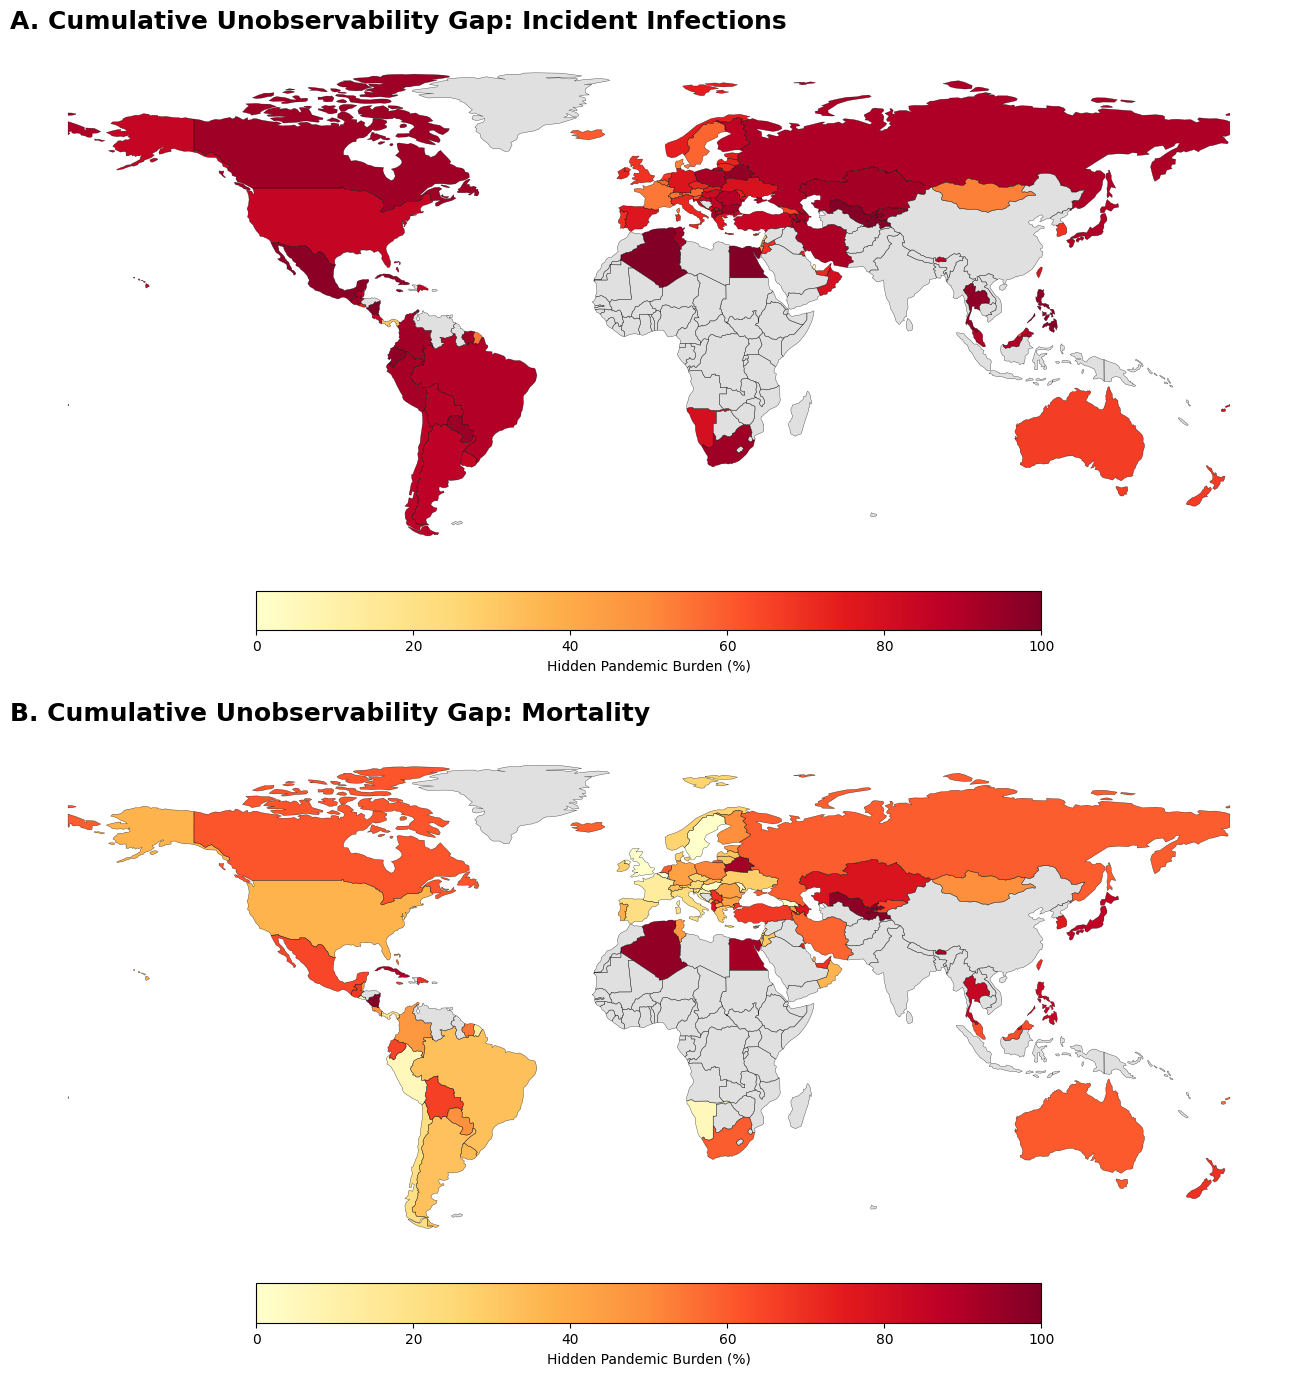

✅ Map successfully saved to Archaeology_Global_Results/Global_Unobservability_Maps_Figure2.png


In [5]:
wmd_countries = df_wmd_full['country_name'].unique()
print(f"Starting Batch Processing for {len(wmd_countries)} countries (Silent Mode)...")

country_results, wave_results = [], []

for wmd_country in wmd_countries:
    try:
        result = process_country(wmd_country)
        if result:
            country_results.append(result[0])
            wave_results.extend(result[1])
    except Exception:
        pass 
    gc.collect()

pd.DataFrame(country_results).to_csv(os.path.join(OUTPUT_DIR, "Country_Summary_Lancet.csv"), index=False)
pd.DataFrame(wave_results).to_csv(os.path.join(OUTPUT_DIR, "Wave_Stats_Lancet.csv"), index=False)
print("✅ Batch process complete! Global CSVs exported.")

# Generate Global Unobservability Map
print("\nGenerating global unobservability map (Figure 2)...")
url_map = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url_map).rename(columns={'NAME': 'name', 'POP_EST': 'pop_est'})
world = world[(world.pop_est > 0) & (world.name != "Antarctica")]
df_map = pd.DataFrame(country_results)

corrections = {"United States": "United States of America", "Czech Republic": "Czechia", "Dominican Republic": "Dominican Rep.", "Bosnia and Herzegovina": "Bosnia and Herz."}
df_map['Country_Map'] = df_map['Country'].replace(corrections)
world_data = world.merge(df_map, how='left', left_on='name', right_on='Country_Map')

fig_m, axes_m = plt.subplots(2, 1, figsize=(16, 14))
fig_m.patch.set_facecolor('white')

world_data.plot(column='Unobs_Cases_Bounded_Map (%)', ax=axes_m[0], cmap='YlOrRd', vmin=0, vmax=100, legend=True, legend_kwds={'label': 'Hidden Pandemic Burden (%)', 'orientation': 'horizontal', 'shrink': 0.5, 'pad': 0.05}, missing_kwds={'color': '#e0e0e0', 'label': 'No Data'})
world_data.boundary.plot(ax=axes_m[0], linewidth=0.3, color='black', alpha=0.7)
axes_m[0].set_title('A. Cumulative Unobservability Gap: Incident Infections', fontsize=18, fontweight='bold', pad=15, loc='left')
axes_m[0].set_axis_off()

world_data.plot(column='Unobs_Deaths_Bounded_Map (%)', ax=axes_m[1], cmap='YlOrRd', vmin=0, vmax=100, legend=True, legend_kwds={'label': 'Hidden Pandemic Burden (%)', 'orientation': 'horizontal', 'shrink': 0.5, 'pad': 0.05}, missing_kwds={'color': '#e0e0e0', 'label': 'No Data'})
world_data.boundary.plot(ax=axes_m[1], linewidth=0.3, color='black', alpha=0.7)
axes_m[1].set_title('B. Cumulative Unobservability Gap: Mortality', fontsize=18, fontweight='bold', pad=15, loc='left')
axes_m[1].set_axis_off()

plt.tight_layout()
out_img_m = os.path.join(OUTPUT_DIR, "Global_Unobservability_Maps_Figure2.png")
plt.savefig(out_img_m, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Map successfully saved to {out_img_m}")

## Individual Case Studies
Run the cell below to visualize the Latent Incidence Dashboard and the Error Evolution Audit for a specific country (e.g., `"Spain"`, `"United States"`, `"United Kingdom"`).

Processing epidemiological reconstruction for Spain...


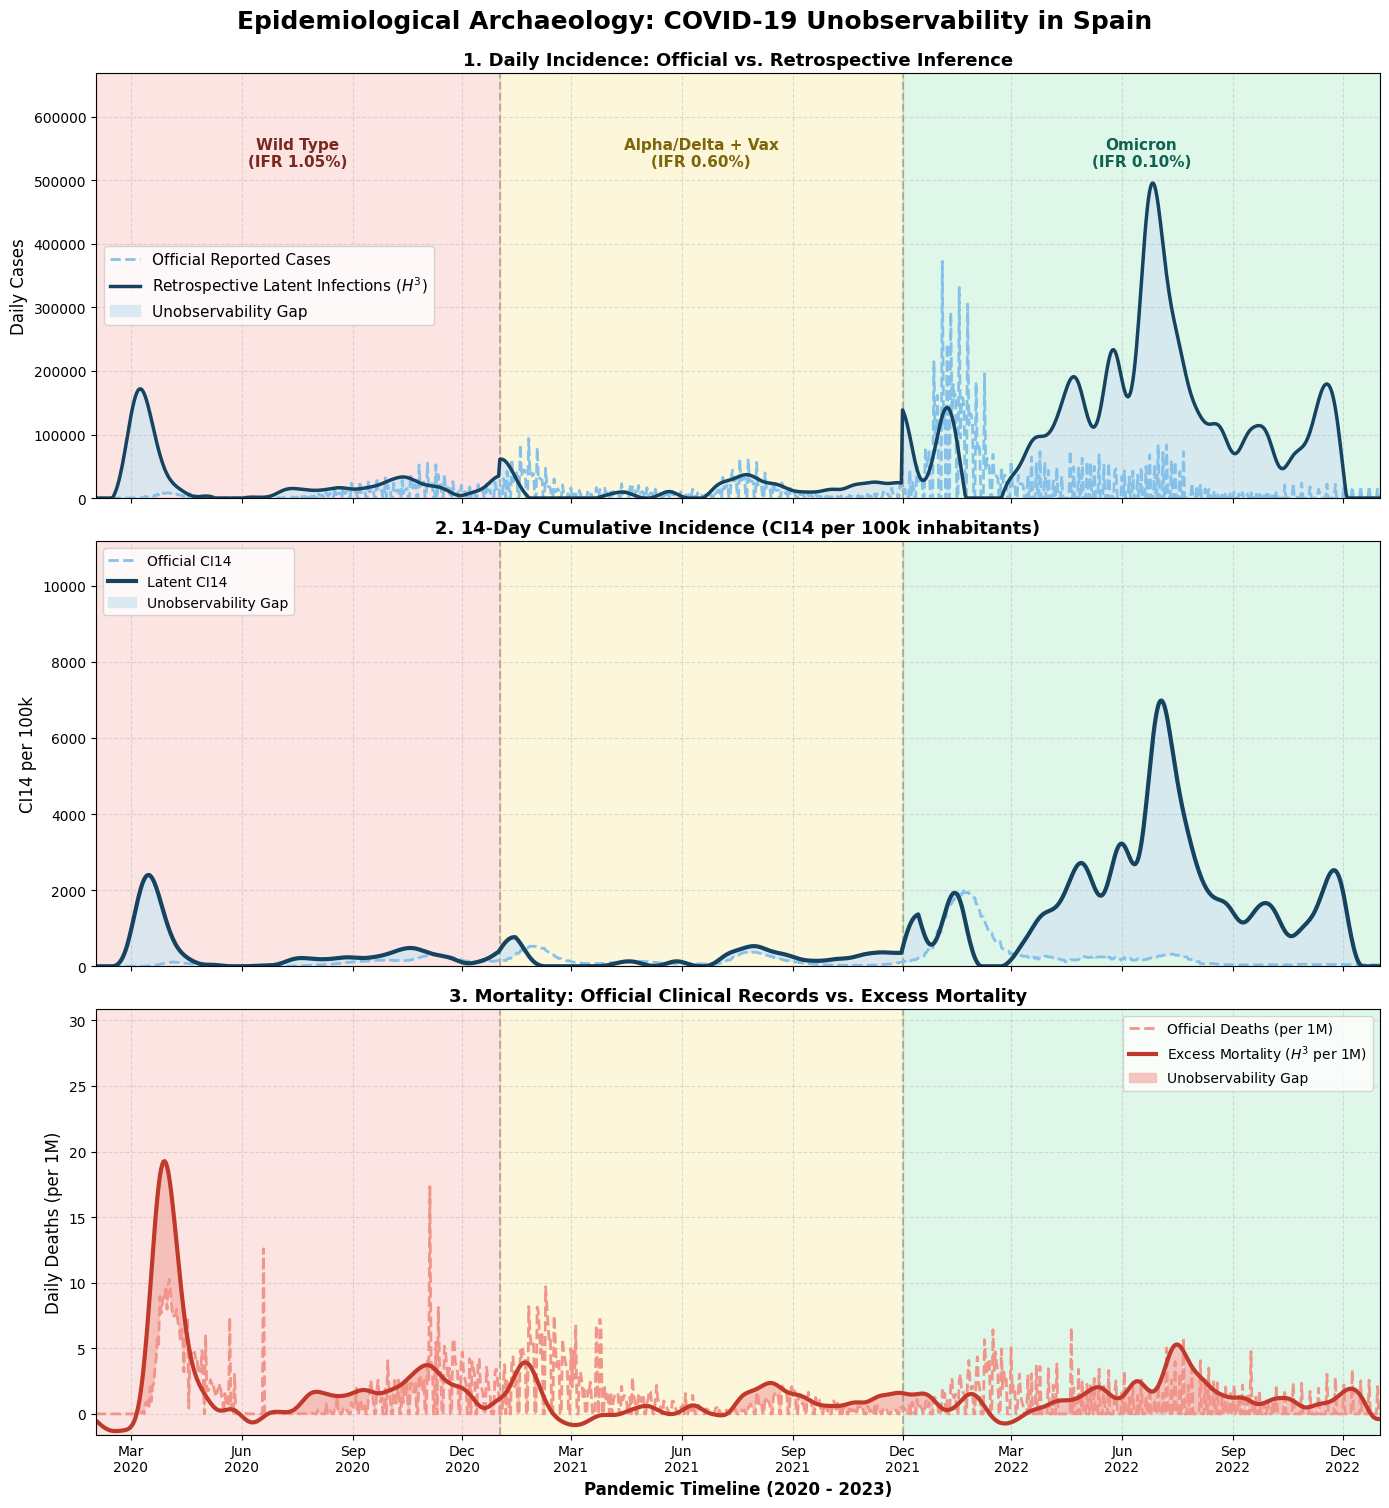

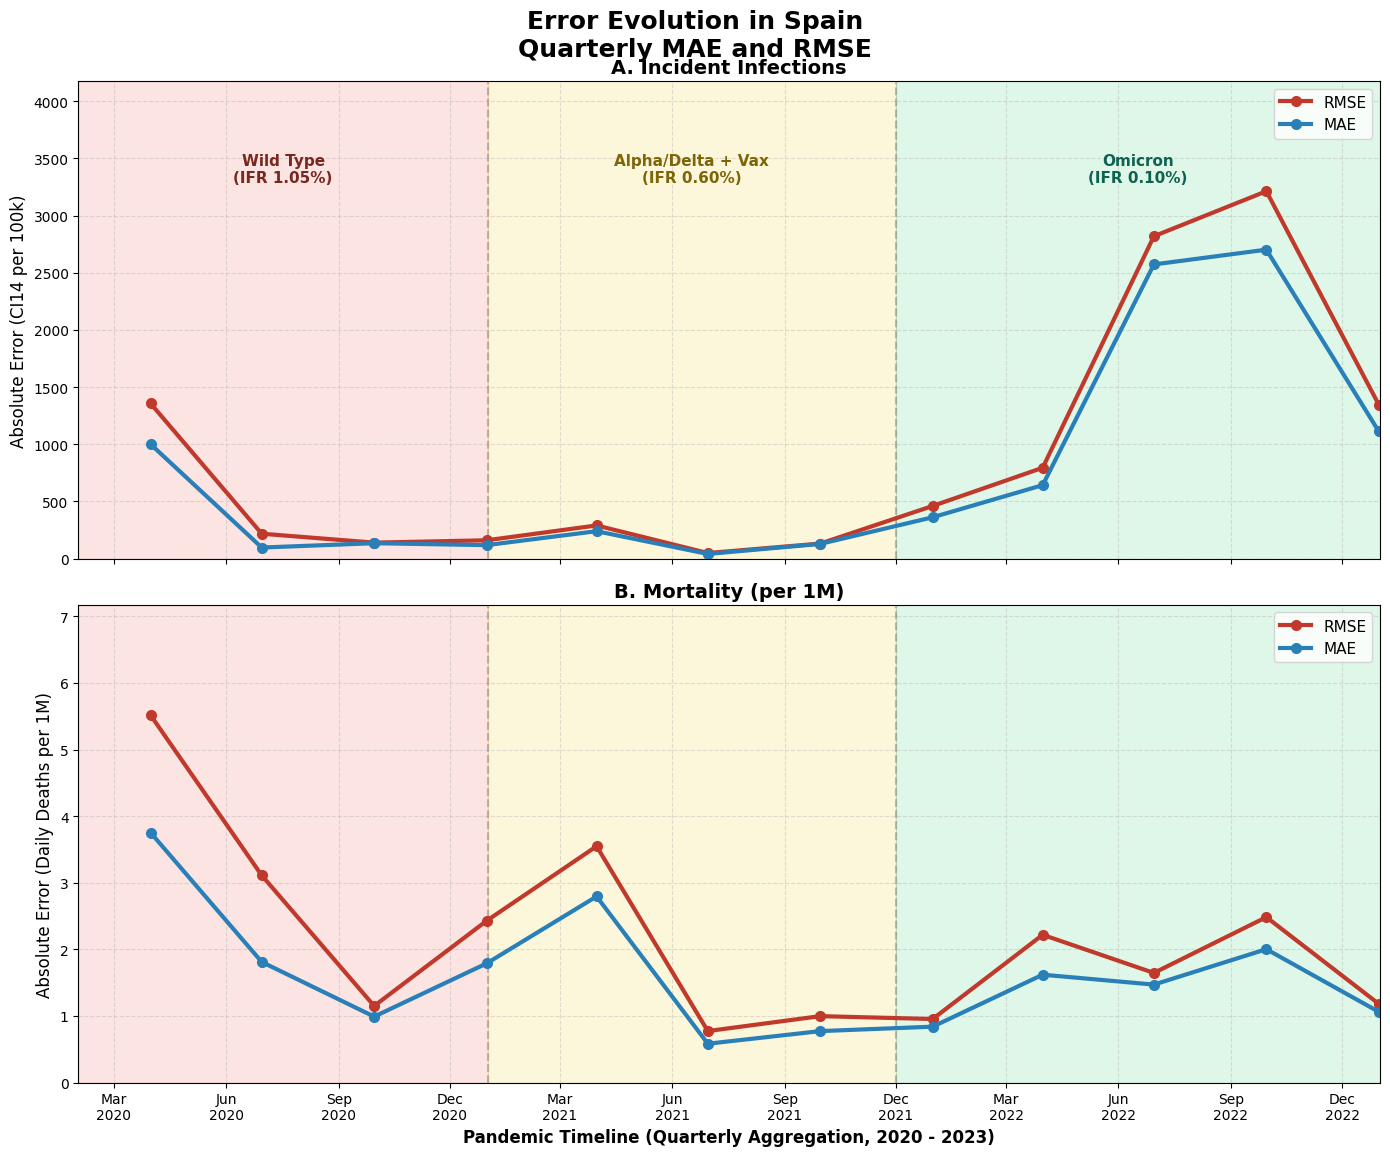

In [6]:
# Change the country name below to generate the dashboards
target_country = "Spain"

print(f"Processing epidemiological reconstruction for {target_country}...")
result_single = process_country(target_country)

if result_single is not None:
    plot_country_dashboard(target_country, result_single)
    plot_error_evolution(target_country, result_single)
else:
    print(f"⚠️ Could not process '{target_country}'. Please check data availability or spelling.")

## Historical Benchmark: The 1918 Influenza Pandemic
**Cross-National Zero-Testing Environment Analysis**

To validate the universal applicability and structural stability of the *Epidemiological Archaeology* framework, we apply the $H^3$ topological regularization to the 1918 influenza pandemic across four distinct geographical, demographic, and reporting scenarios:
1. **United States:** Weekly reporting resolution.
2. **England & Wales:** Weekly reporting resolution.
3. **Spain:** Monthly aggregated reporting resolution.
4. **British India:** Monthly aggregated reporting resolution (representing the most severe mortality burden globally under colonial reporting constraints).

### Epidemiological Parameters & Historical Data Sources
The mathematical engine utilizes parameters and baseline mortality curves extracted from established epidemiological literature and historical registries:

* **Infection Fatality Ratio (IFR): 2.5%** (Taubenberger & Morens, 2006. *Emerging Infectious Diseases*. [DOI: 10.3201/eid1201.050979](https://dx.doi.org/10.3201%2Feid1201.050979))
* **Clinical Delay ($\tau$): 7 days** (Chowell et al., 2008. *Proc. R. Soc. B.* [DOI: 10.1098/rspb.2007.1477](https://doi.org/10.1098/rspb.2007.1477))
* **United States Data:** Based on historical mortality scaling (Population ~103M).
* **England & Wales Data:** Chowell et al. (2008). 
* **Spain Data:** Chowell et al. (2014) *BMC Infectious Diseases* [DOI: 10.1186/1471-2334-14-371](https://doi.org/10.1186/1471-2334-14-371) and *Instituto Nacional de Estadística (INE)* 1920 Yearbook.
* **British India Data:** Based on Chandra et al. (2012) *Demography* [DOI: 10.1007/s13524-012-0132-6](https://doi.org/10.1007/s13524-012-0132-6) and Mills (1986), capturing the massive Autumn 1918 wave across a population of ~315M.

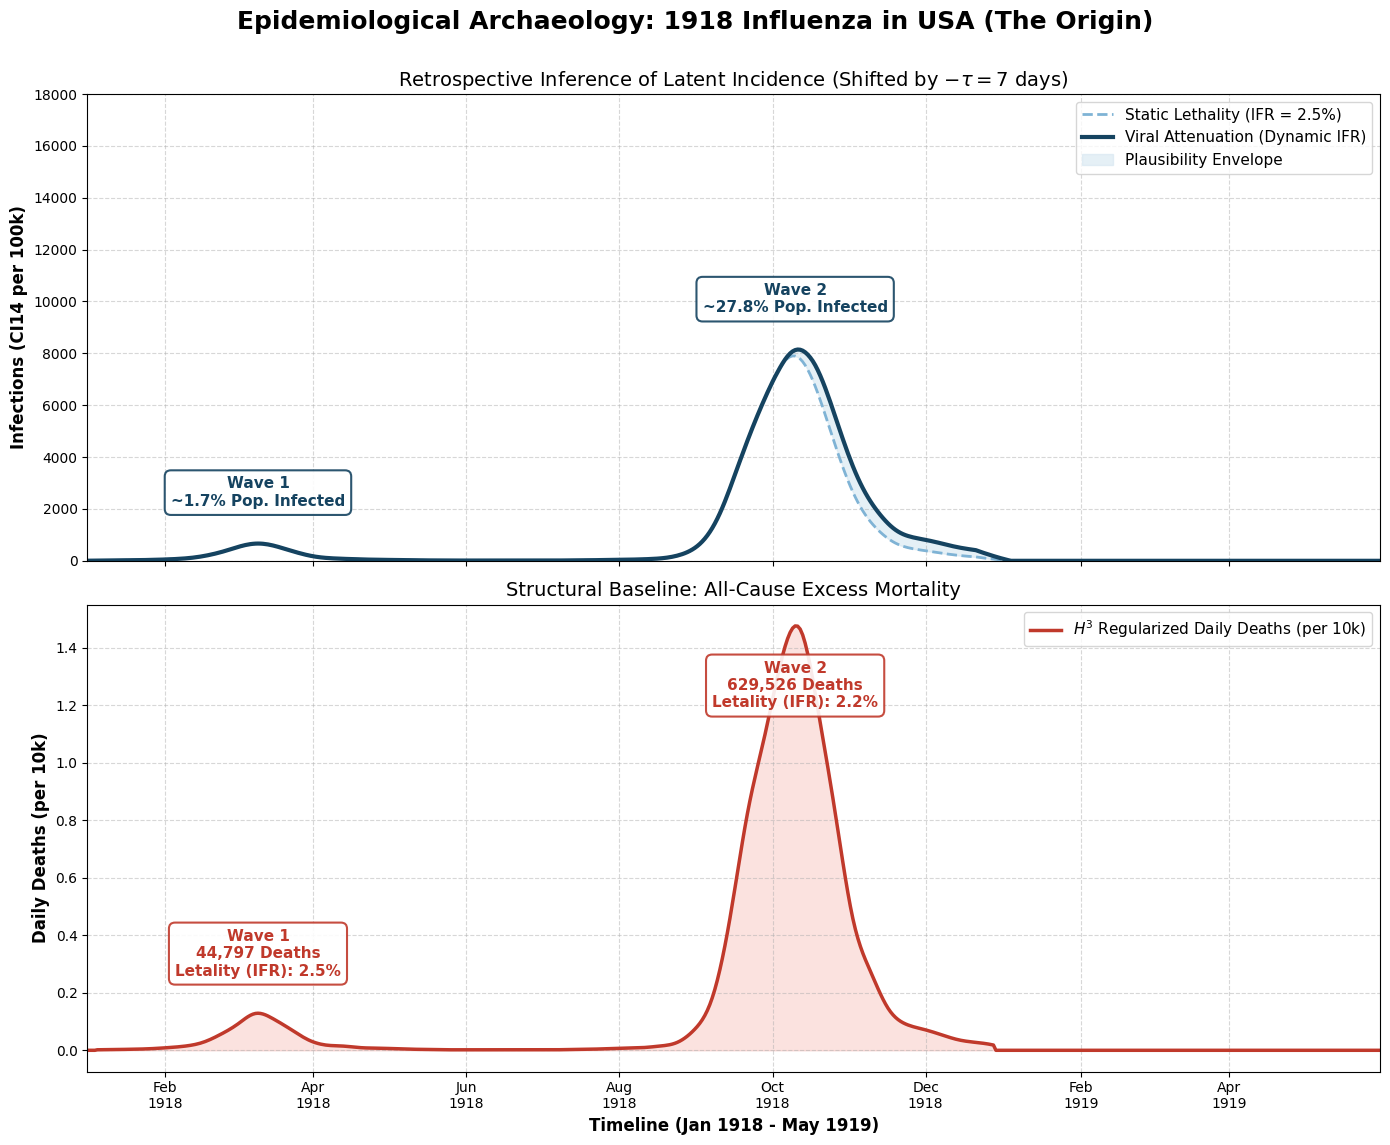

In [3]:
#UNITED STATES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.signal import find_peaks
import matplotlib.dates as mdates
from datetime import timedelta

TAU_SHIFT = 7                 
TOTAL_DEATHS = 675000         
POPULATION = 103000000        

IFR_PEAK = 0.025              
IFR_ENDEMIC = 0.001           
K_DECAY = 0.015               

fechas_semanales_us = pd.date_range(start="1918-01-05", periods=52, freq='W-SAT')
muertes_semanales_us_raw = np.array([
    100, 150, 200, 300, 500, 800, 1500, 3000, 5000, 7000, 6000, 4000, 2000,
    1000, 800, 500, 400, 300, 200, 150, 100, 100, 100, 100, 100, 100, 100, 150, 200, 300, 400, 500, 800, 1500,
    4000, 10000, 25000, 45000, 60000, 75000, 80000, 65000, 45000, 25000, 15000, 8000, 5000,
    4000, 3000, 2000, 1500, 1000
])

dias_numericos = (fechas_semanales_us - fechas_semanales_us.min()).days
cs = CubicSpline(dias_numericos, muertes_semanales_us_raw)

fechas_diarias_full = pd.date_range(start="1918-01-01", end="1919-05-31", freq='D')
dias_evaluacion_full = (fechas_diarias_full - fechas_semanales_us.min()).days

valid_mask = (fechas_diarias_full >= fechas_semanales_us.min()) & (fechas_diarias_full <= fechas_semanales_us.max())
muertes_diarias_h3 = np.zeros(len(fechas_diarias_full))
muertes_diarias_h3[valid_mask] = np.maximum(cs(dias_evaluacion_full[valid_mask]) / 7.0, 0)

muertes_diarias_h3 = muertes_diarias_h3 * (TOTAL_DEATHS / np.sum(muertes_diarias_h3))
df_daily = pd.DataFrame({'Date': fechas_diarias_full, 'Deaths_H3': muertes_diarias_h3})
df_daily['Deaths_per_10k'] = df_daily['Deaths_H3'] * 10000 / POPULATION

t_peak_idx = np.argmax(df_daily['Deaths_H3'])
t_array = np.arange(len(df_daily))
ifr_dynamic = np.where(t_array < t_peak_idx, IFR_PEAK, IFR_ENDEMIC + (IFR_PEAK - IFR_ENDEMIC) * np.exp(-K_DECAY * (t_array - t_peak_idx)))

df_daily['Infection_Date'] = df_daily['Date'] - timedelta(days=TAU_SHIFT)
df_daily['Daily_Infections_Static'] = df_daily['Deaths_H3'] / IFR_PEAK
df_daily['Daily_Infections_Dynamic'] = df_daily['Deaths_H3'] / ifr_dynamic

factor_100k = POPULATION / 100000
df_infections = df_daily[['Infection_Date', 'Daily_Infections_Static', 'Daily_Infections_Dynamic']].dropna().set_index('Infection_Date')
df_infections['CI14_Inf_Static'] = df_infections['Daily_Infections_Static'].rolling(window=14, min_periods=1).sum() / factor_100k
df_infections['CI14_Inf_Dynamic'] = df_infections['Daily_Infections_Dynamic'].rolling(window=14, min_periods=1).sum() / factor_100k

df_plot = pd.merge(df_daily[['Date', 'Deaths_H3', 'Deaths_per_10k']], df_infections[['CI14_Inf_Static', 'CI14_Inf_Dynamic']], left_on='Date', right_index=True, how='left').fillna(0)

peaks_idx, _ = find_peaks(df_plot['Deaths_H3'], distance=40, height=500)
valleys_idx, _ = find_peaks(-df_plot['Deaths_H3'])
boundaries = np.sort(np.concatenate(([0], valleys_idx, [len(df_plot)-1])))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Epidemiological Archaeology: 1918 Influenza in USA (The Origin)', fontsize=18, fontweight='bold', y=0.95)

color_static, color_dynamic, color_fill = '#7FB3D5', '#154360', '#D4E6F1'     
color_death, color_death_fill = '#C0392B', '#F5B7B1' 

ax1.plot(df_plot['Date'], df_plot['CI14_Inf_Static'], color=color_static, linewidth=2, linestyle='--', label=r'Static Lethality (IFR = 2.5%)')
ax1.plot(df_plot['Date'], df_plot['CI14_Inf_Dynamic'], color=color_dynamic, linewidth=3, label=r'Viral Attenuation (Dynamic IFR)')
ax1.fill_between(df_plot['Date'], df_plot['CI14_Inf_Static'], df_plot['CI14_Inf_Dynamic'], color=color_fill, alpha=0.6, label='Plausibility Envelope')

for i, p_idx in enumerate(peaks_idx):
    peak_date_inf, peak_val_inf = df_plot['Date'].iloc[p_idx], df_plot['CI14_Inf_Dynamic'].iloc[p_idx]
    start_idx, end_idx = boundaries[boundaries < p_idx].max(), boundaries[boundaries > p_idx].min()
    wave_infected = df_daily['Daily_Infections_Dynamic'].iloc[start_idx:end_idx].sum()
    
    y_offset, v_align = (-20, 'top') if peak_val_inf > 12000 else (25, 'bottom')
    ax1.annotate(f"Wave {i+1}\n~{(wave_infected/POPULATION)*100:.1f}% Pop. Infected", xy=(peak_date_inf, peak_val_inf), 
                 xytext=(0, y_offset), textcoords='offset points', ha='center', va=v_align, 
                 fontsize=11, fontweight='bold', color=color_dynamic, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=color_dynamic, lw=1.5, alpha=0.9))

ax1.set_title(r'Retrospective Inference of Latent Incidence (Shifted by $-\tau=7$ days)', fontsize=14)
ax1.set_ylabel('Infections (CI14 per 100k)', fontsize=12, fontweight='bold')
ax1.set_xlim([pd.Timestamp('1918-01-01'), pd.Timestamp('1919-05-31')])
ax1.set_ylim(0, 18000)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(df_plot['Date'], df_plot['Deaths_per_10k'], color=color_death, linewidth=2.5, label=r'$H^3$ Regularized Daily Deaths (per 10k)')
ax2.fill_between(df_plot['Date'], 0, df_plot['Deaths_per_10k'], color=color_death_fill, alpha=0.4)

max_death_10k = df_plot['Deaths_per_10k'].max()
for i, p_idx in enumerate(peaks_idx):
    peak_date_dead, peak_val_dead_10k = df_plot['Date'].iloc[p_idx], df_plot['Deaths_per_10k'].iloc[p_idx]
    start_idx, end_idx = boundaries[boundaries < p_idx].max(), boundaries[boundaries > p_idx].min()
    wave_dead = df_daily['Deaths_H3'].iloc[start_idx:end_idx].sum()
    wave_infected = df_daily['Daily_Infections_Dynamic'].iloc[start_idx:end_idx].sum()
    wave_ifr = (wave_dead / wave_infected) * 100 if wave_infected > 0 else 0
    dead_str = f"~{wave_dead/1e6:.2f}M Deaths" if wave_dead > 1e6 else f"{int(wave_dead):,} Deaths"
    
    y_offset, v_align = (-25, 'top') if peak_val_dead_10k > (max_death_10k * 0.7) else (25, 'bottom')
    ax2.annotate(f"Wave {i+1}\n{dead_str}\nLetality (IFR): {wave_ifr:.1f}%", xy=(peak_date_dead, peak_val_dead_10k), 
                 xytext=(0, y_offset), textcoords='offset points', ha='center', va=v_align, 
                 fontsize=11, fontweight='bold', color=color_death, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=color_death, lw=1.5, alpha=0.9))

ax2.set_title('Structural Baseline: All-Cause Excess Mortality', fontsize=14)
ax2.set_ylabel('Daily Deaths (per 10k)', fontsize=12, fontweight='bold') 
ax2.set_xlabel('Timeline (Jan 1918 - May 1919)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) 
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

plt.tight_layout()
plt.subplots_adjust(top=0.88) 
plt.savefig("1918_USA.png", dpi=300, bbox_inches='tight')
plt.show()

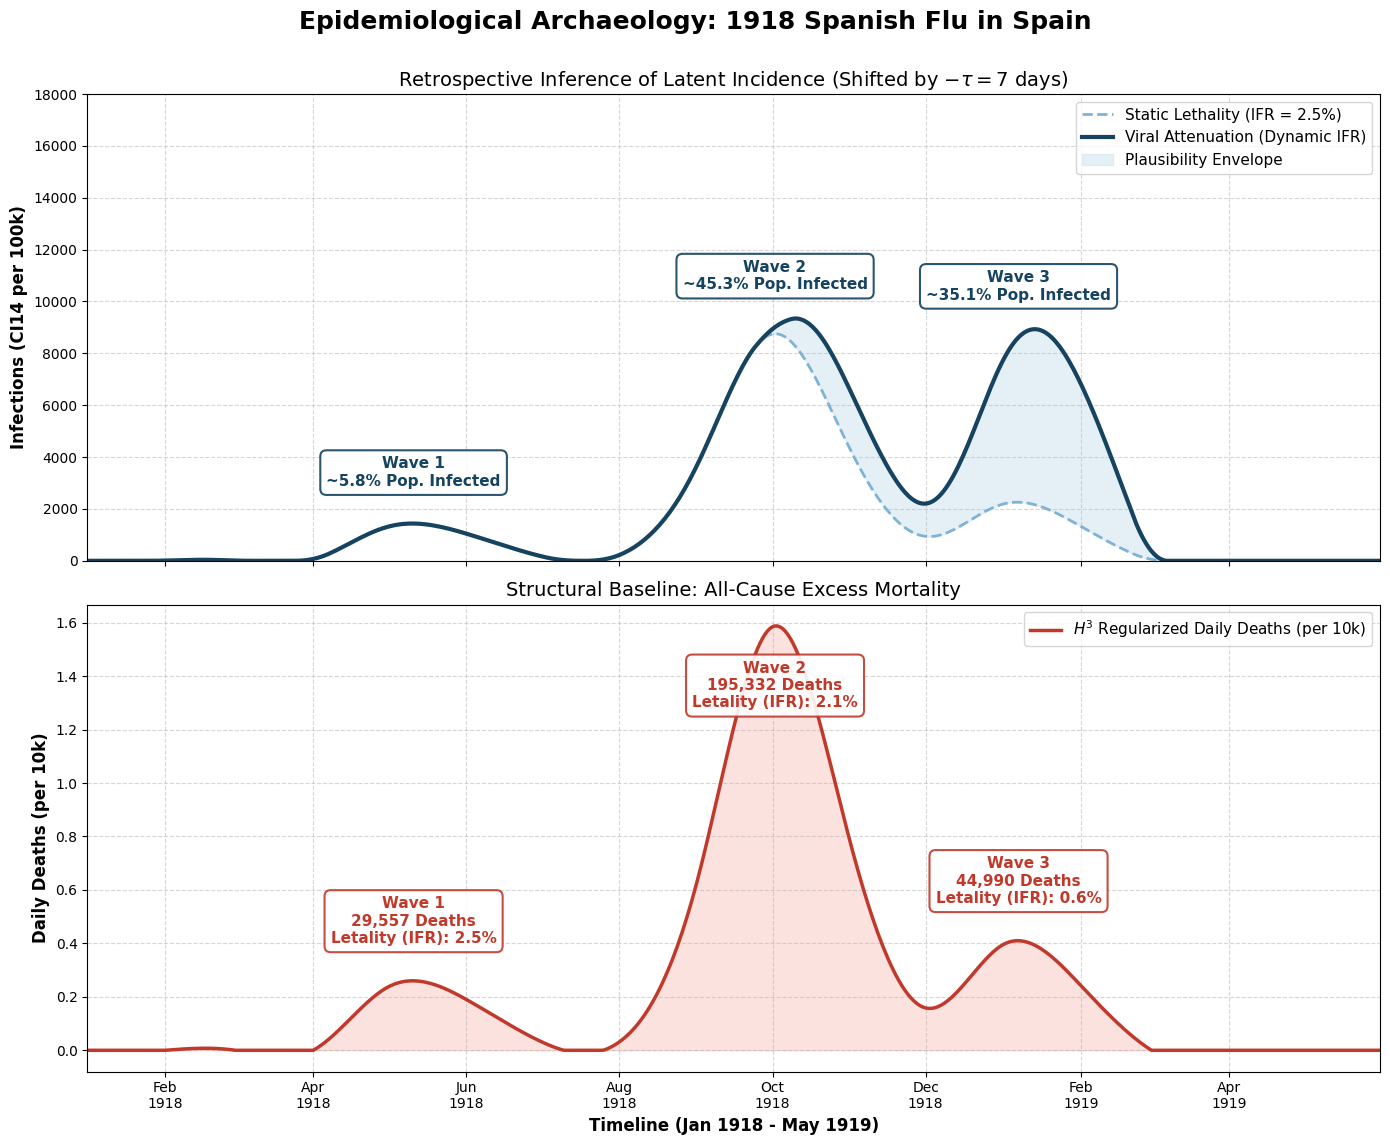

In [4]:
#SPAIN

TAU_SHIFT = 7                 
TOTAL_DEATHS = 270170         
POPULATION = 20500000         

IFR_PEAK = 0.025              
IFR_ENDEMIC = 0.001           
K_DECAY = 0.015               

meses_1918_1919 = pd.date_range(start="1918-01-01", end="1919-04-30", freq='MS')
muertes_mensuales = [0, 0, 0, 0, 15000, 12000, 2000, 2000, 40000, 100000, 49000, 10000, 25000, 15170, 0, 0]

dias_numericos = (meses_1918_1919 - meses_1918_1919.min()).days
cs = CubicSpline(dias_numericos, muertes_mensuales)

fechas_diarias_full = pd.date_range(start="1918-01-01", end="1919-05-31", freq='D')
dias_evaluacion_full = (fechas_diarias_full - meses_1918_1919.min()).days

valid_mask = (fechas_diarias_full >= meses_1918_1919.min()) & (fechas_diarias_full <= meses_1918_1919.max())
muertes_diarias_h3 = np.zeros(len(fechas_diarias_full))
muertes_diarias_h3[valid_mask] = np.maximum(cs(dias_evaluacion_full[valid_mask]) / 30.0, 0)

muertes_diarias_h3 = muertes_diarias_h3 * (TOTAL_DEATHS / np.sum(muertes_diarias_h3))
df_daily = pd.DataFrame({'Date': fechas_diarias_full, 'Deaths_H3': muertes_diarias_h3})
df_daily['Deaths_per_10k'] = df_daily['Deaths_H3'] * 10000 / POPULATION

t_peak_idx = np.argmax(df_daily['Deaths_H3'])
t_array = np.arange(len(df_daily))
ifr_dynamic = np.where(t_array < t_peak_idx, IFR_PEAK, IFR_ENDEMIC + (IFR_PEAK - IFR_ENDEMIC) * np.exp(-K_DECAY * (t_array - t_peak_idx)))

df_daily['Infection_Date'] = df_daily['Date'] - timedelta(days=TAU_SHIFT)
df_daily['Daily_Infections_Static'] = df_daily['Deaths_H3'] / IFR_PEAK
df_daily['Daily_Infections_Dynamic'] = df_daily['Deaths_H3'] / ifr_dynamic

factor_100k = POPULATION / 100000
df_infections = df_daily[['Infection_Date', 'Daily_Infections_Static', 'Daily_Infections_Dynamic']].dropna().set_index('Infection_Date')
df_infections['CI14_Inf_Static'] = df_infections['Daily_Infections_Static'].rolling(window=14, min_periods=1).sum() / factor_100k
df_infections['CI14_Inf_Dynamic'] = df_infections['Daily_Infections_Dynamic'].rolling(window=14, min_periods=1).sum() / factor_100k

df_plot = pd.merge(df_daily[['Date', 'Deaths_H3', 'Deaths_per_10k']], df_infections[['CI14_Inf_Static', 'CI14_Inf_Dynamic']], left_on='Date', right_index=True, how='left').fillna(0)

peaks_idx, _ = find_peaks(df_plot['Deaths_H3'], distance=40, height=200)
valleys_idx, _ = find_peaks(-df_plot['Deaths_H3'])
boundaries = np.sort(np.concatenate(([0], valleys_idx, [len(df_plot)-1])))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Epidemiological Archaeology: 1918 Spanish Flu in Spain', fontsize=18, fontweight='bold', y=0.95)

color_static, color_dynamic, color_fill = '#7FB3D5', '#154360', '#D4E6F1'     
color_death, color_death_fill = '#C0392B', '#F5B7B1' 

ax1.plot(df_plot['Date'], df_plot['CI14_Inf_Static'], color=color_static, linewidth=2, linestyle='--', label=r'Static Lethality (IFR = 2.5%)')
ax1.plot(df_plot['Date'], df_plot['CI14_Inf_Dynamic'], color=color_dynamic, linewidth=3, label=r'Viral Attenuation (Dynamic IFR)')
ax1.fill_between(df_plot['Date'], df_plot['CI14_Inf_Static'], df_plot['CI14_Inf_Dynamic'], color=color_fill, alpha=0.6, label='Plausibility Envelope')

for i, p_idx in enumerate(peaks_idx):
    peak_date_inf, peak_val_inf = df_plot['Date'].iloc[p_idx], df_plot['CI14_Inf_Dynamic'].iloc[p_idx]
    start_idx, end_idx = boundaries[boundaries < p_idx].max(), boundaries[boundaries > p_idx].min()
    wave_infected = df_daily['Daily_Infections_Dynamic'].iloc[start_idx:end_idx].sum()
    
    y_offset, v_align = (-20, 'top') if peak_val_inf > 12000 else (25, 'bottom')
    ax1.annotate(f"Wave {i+1}\n~{(wave_infected/POPULATION)*100:.1f}% Pop. Infected", xy=(peak_date_inf, peak_val_inf), 
                 xytext=(0, y_offset), textcoords='offset points', ha='center', va=v_align, 
                 fontsize=11, fontweight='bold', color=color_dynamic, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=color_dynamic, lw=1.5, alpha=0.9))

ax1.set_title(r'Retrospective Inference of Latent Incidence (Shifted by $-\tau=7$ days)', fontsize=14)
ax1.set_ylabel('Infections (CI14 per 100k)', fontsize=12, fontweight='bold')
ax1.set_xlim([pd.Timestamp('1918-01-01'), pd.Timestamp('1919-05-31')])
ax1.set_ylim(0, 18000)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(df_plot['Date'], df_plot['Deaths_per_10k'], color=color_death, linewidth=2.5, label=r'$H^3$ Regularized Daily Deaths (per 10k)')
ax2.fill_between(df_plot['Date'], 0, df_plot['Deaths_per_10k'], color=color_death_fill, alpha=0.4)

max_death_10k = df_plot['Deaths_per_10k'].max()
for i, p_idx in enumerate(peaks_idx):
    peak_date_dead, peak_val_dead_10k = df_plot['Date'].iloc[p_idx], df_plot['Deaths_per_10k'].iloc[p_idx]
    start_idx, end_idx = boundaries[boundaries < p_idx].max(), boundaries[boundaries > p_idx].min()
    wave_dead = df_daily['Deaths_H3'].iloc[start_idx:end_idx].sum()
    wave_infected = df_daily['Daily_Infections_Dynamic'].iloc[start_idx:end_idx].sum()
    wave_ifr = (wave_dead / wave_infected) * 100 if wave_infected > 0 else 0
    dead_str = f"~{wave_dead/1e6:.2f}M Deaths" if wave_dead > 1e6 else f"{int(wave_dead):,} Deaths"
    
    y_offset, v_align = (-25, 'top') if peak_val_dead_10k > (max_death_10k * 0.7) else (25, 'bottom')
    ax2.annotate(f"Wave {i+1}\n{dead_str}\nLetality (IFR): {wave_ifr:.1f}%", xy=(peak_date_dead, peak_val_dead_10k), 
                 xytext=(0, y_offset), textcoords='offset points', ha='center', va=v_align, 
                 fontsize=11, fontweight='bold', color=color_death, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=color_death, lw=1.5, alpha=0.9))

ax2.set_title('Structural Baseline: All-Cause Excess Mortality', fontsize=14)
ax2.set_ylabel('Daily Deaths (per 10k)', fontsize=12, fontweight='bold') 
ax2.set_xlabel('Timeline (Jan 1918 - May 1919)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) 
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

plt.tight_layout()
plt.subplots_adjust(top=0.88) 
plt.savefig("1918_Spain.png", dpi=300, bbox_inches='tight')
plt.show()

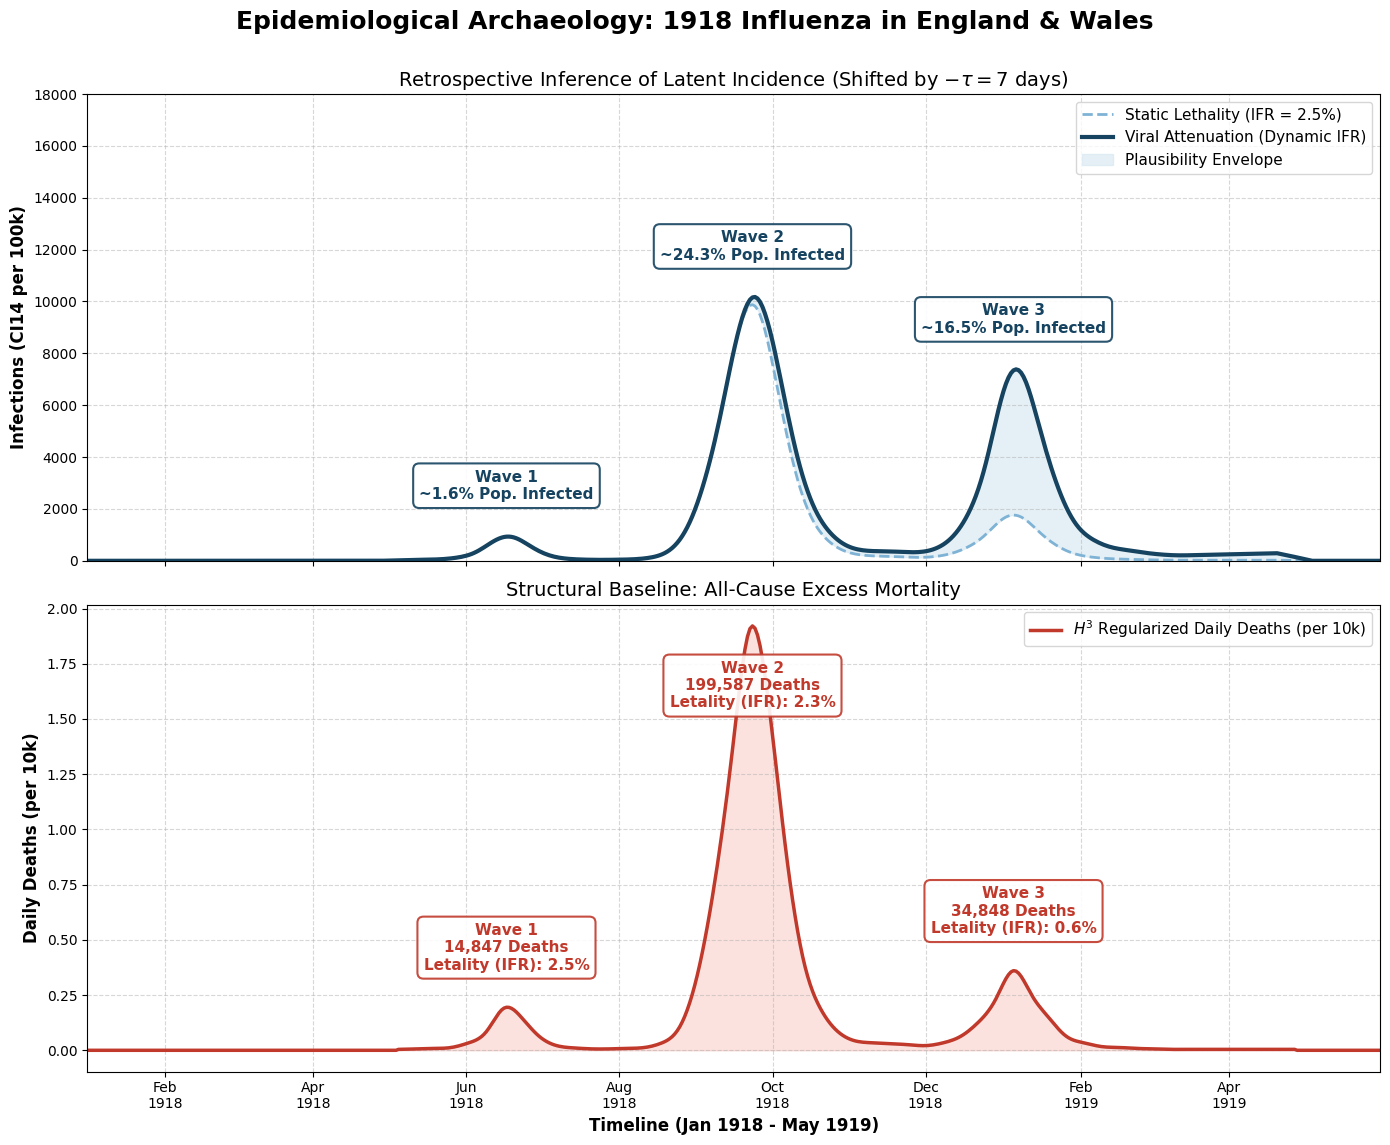

In [5]:
#ENGLAND AND WALES

TAU_SHIFT = 7                 
TOTAL_DEATHS = 250000         
POPULATION = 36000000         

IFR_PEAK = 0.025              
IFR_ENDEMIC = 0.001           
K_DECAY = 0.015               

fechas_semanales_uk = pd.date_range(start="1918-05-01", periods=52, freq='W')
muertes_semanales_uk_raw = np.array([
    100, 150, 200, 300, 800, 2000, 4500, 3500, 1500, 500, 250, 150, 150, 200, 300, 
    800, 2500, 8000, 18000, 32000, 45000, 38000, 22000, 10000, 4500, 2000, 1000, 
    800, 700, 600, 500, 800, 1500, 3000, 5500, 8500, 6000, 3500, 1500, 800, 
    400, 300, 200, 150, 100, 100, 100, 100, 100, 100, 100, 100
])

dias_numericos = (fechas_semanales_uk - fechas_semanales_uk.min()).days
cs = CubicSpline(dias_numericos, muertes_semanales_uk_raw)

fechas_diarias_full = pd.date_range(start="1918-01-01", end="1919-05-31", freq='D')
dias_evaluacion_full = (fechas_diarias_full - fechas_semanales_uk.min()).days

valid_mask = (fechas_diarias_full >= fechas_semanales_uk.min()) & (fechas_diarias_full <= fechas_semanales_uk.max())
muertes_diarias_h3 = np.zeros(len(fechas_diarias_full))
muertes_diarias_h3[valid_mask] = np.maximum(cs(dias_evaluacion_full[valid_mask]) / 7.0, 0)

muertes_diarias_h3 = muertes_diarias_h3 * (TOTAL_DEATHS / np.sum(muertes_diarias_h3))
df_daily = pd.DataFrame({'Date': fechas_diarias_full, 'Deaths_H3': muertes_diarias_h3})
df_daily['Deaths_per_10k'] = df_daily['Deaths_H3'] * 10000 / POPULATION

t_peak_idx = np.argmax(df_daily['Deaths_H3'])
t_array = np.arange(len(df_daily))
ifr_dynamic = np.where(t_array < t_peak_idx, IFR_PEAK, IFR_ENDEMIC + (IFR_PEAK - IFR_ENDEMIC) * np.exp(-K_DECAY * (t_array - t_peak_idx)))

df_daily['Infection_Date'] = df_daily['Date'] - timedelta(days=TAU_SHIFT)
df_daily['Daily_Infections_Static'] = df_daily['Deaths_H3'] / IFR_PEAK
df_daily['Daily_Infections_Dynamic'] = df_daily['Deaths_H3'] / ifr_dynamic

factor_100k = POPULATION / 100000
df_infections = df_daily[['Infection_Date', 'Daily_Infections_Static', 'Daily_Infections_Dynamic']].dropna().set_index('Infection_Date')
df_infections['CI14_Inf_Static'] = df_infections['Daily_Infections_Static'].rolling(window=14, min_periods=1).sum() / factor_100k
df_infections['CI14_Inf_Dynamic'] = df_infections['Daily_Infections_Dynamic'].rolling(window=14, min_periods=1).sum() / factor_100k

df_plot = pd.merge(df_daily[['Date', 'Deaths_H3', 'Deaths_per_10k']], df_infections[['CI14_Inf_Static', 'CI14_Inf_Dynamic']], left_on='Date', right_index=True, how='left').fillna(0)

peaks_idx, _ = find_peaks(df_plot['Deaths_H3'], distance=40, height=200)
valleys_idx, _ = find_peaks(-df_plot['Deaths_H3'])
boundaries = np.sort(np.concatenate(([0], valleys_idx, [len(df_plot)-1])))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Epidemiological Archaeology: 1918 Influenza in England & Wales', fontsize=18, fontweight='bold', y=0.95)

color_static, color_dynamic, color_fill = '#7FB3D5', '#154360', '#D4E6F1'     
color_death, color_death_fill = '#C0392B', '#F5B7B1' 

ax1.plot(df_plot['Date'], df_plot['CI14_Inf_Static'], color=color_static, linewidth=2, linestyle='--', label=r'Static Lethality (IFR = 2.5%)')
ax1.plot(df_plot['Date'], df_plot['CI14_Inf_Dynamic'], color=color_dynamic, linewidth=3, label=r'Viral Attenuation (Dynamic IFR)')
ax1.fill_between(df_plot['Date'], df_plot['CI14_Inf_Static'], df_plot['CI14_Inf_Dynamic'], color=color_fill, alpha=0.6, label='Plausibility Envelope')

for i, p_idx in enumerate(peaks_idx):
    peak_date_inf, peak_val_inf = df_plot['Date'].iloc[p_idx], df_plot['CI14_Inf_Dynamic'].iloc[p_idx]
    start_idx, end_idx = boundaries[boundaries < p_idx].max(), boundaries[boundaries > p_idx].min()
    wave_infected = df_daily['Daily_Infections_Dynamic'].iloc[start_idx:end_idx].sum()
    
    y_offset, v_align = (-20, 'top') if peak_val_inf > 12000 else (25, 'bottom')
    ax1.annotate(f"Wave {i+1}\n~{(wave_infected/POPULATION)*100:.1f}% Pop. Infected", xy=(peak_date_inf, peak_val_inf), 
                 xytext=(0, y_offset), textcoords='offset points', ha='center', va=v_align, 
                 fontsize=11, fontweight='bold', color=color_dynamic, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=color_dynamic, lw=1.5, alpha=0.9))

ax1.set_title(r'Retrospective Inference of Latent Incidence (Shifted by $-\tau=7$ days)', fontsize=14)
ax1.set_ylabel('Infections (CI14 per 100k)', fontsize=12, fontweight='bold')
ax1.set_xlim([pd.Timestamp('1918-01-01'), pd.Timestamp('1919-05-31')])
ax1.set_ylim(0, 18000)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(df_plot['Date'], df_plot['Deaths_per_10k'], color=color_death, linewidth=2.5, label=r'$H^3$ Regularized Daily Deaths (per 10k)')
ax2.fill_between(df_plot['Date'], 0, df_plot['Deaths_per_10k'], color=color_death_fill, alpha=0.4)

max_death_10k = df_plot['Deaths_per_10k'].max()
for i, p_idx in enumerate(peaks_idx):
    peak_date_dead, peak_val_dead_10k = df_plot['Date'].iloc[p_idx], df_plot['Deaths_per_10k'].iloc[p_idx]
    start_idx, end_idx = boundaries[boundaries < p_idx].max(), boundaries[boundaries > p_idx].min()
    wave_dead = df_daily['Deaths_H3'].iloc[start_idx:end_idx].sum()
    wave_infected = df_daily['Daily_Infections_Dynamic'].iloc[start_idx:end_idx].sum()
    wave_ifr = (wave_dead / wave_infected) * 100 if wave_infected > 0 else 0
    dead_str = f"~{wave_dead/1e6:.2f}M Deaths" if wave_dead > 1e6 else f"{int(wave_dead):,} Deaths"
    
    y_offset, v_align = (-25, 'top') if peak_val_dead_10k > (max_death_10k * 0.7) else (25, 'bottom')
    ax2.annotate(f"Wave {i+1}\n{dead_str}\nLetality (IFR): {wave_ifr:.1f}%", xy=(peak_date_dead, peak_val_dead_10k), 
                 xytext=(0, y_offset), textcoords='offset points', ha='center', va=v_align, 
                 fontsize=11, fontweight='bold', color=color_death, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=color_death, lw=1.5, alpha=0.9))

ax2.set_title('Structural Baseline: All-Cause Excess Mortality', fontsize=14)
ax2.set_ylabel('Daily Deaths (per 10k)', fontsize=12, fontweight='bold') 
ax2.set_xlabel('Timeline (Jan 1918 - May 1919)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) 
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

plt.tight_layout()
plt.subplots_adjust(top=0.88) 
plt.savefig("1918_UK.png", dpi=300, bbox_inches='tight')
plt.show()

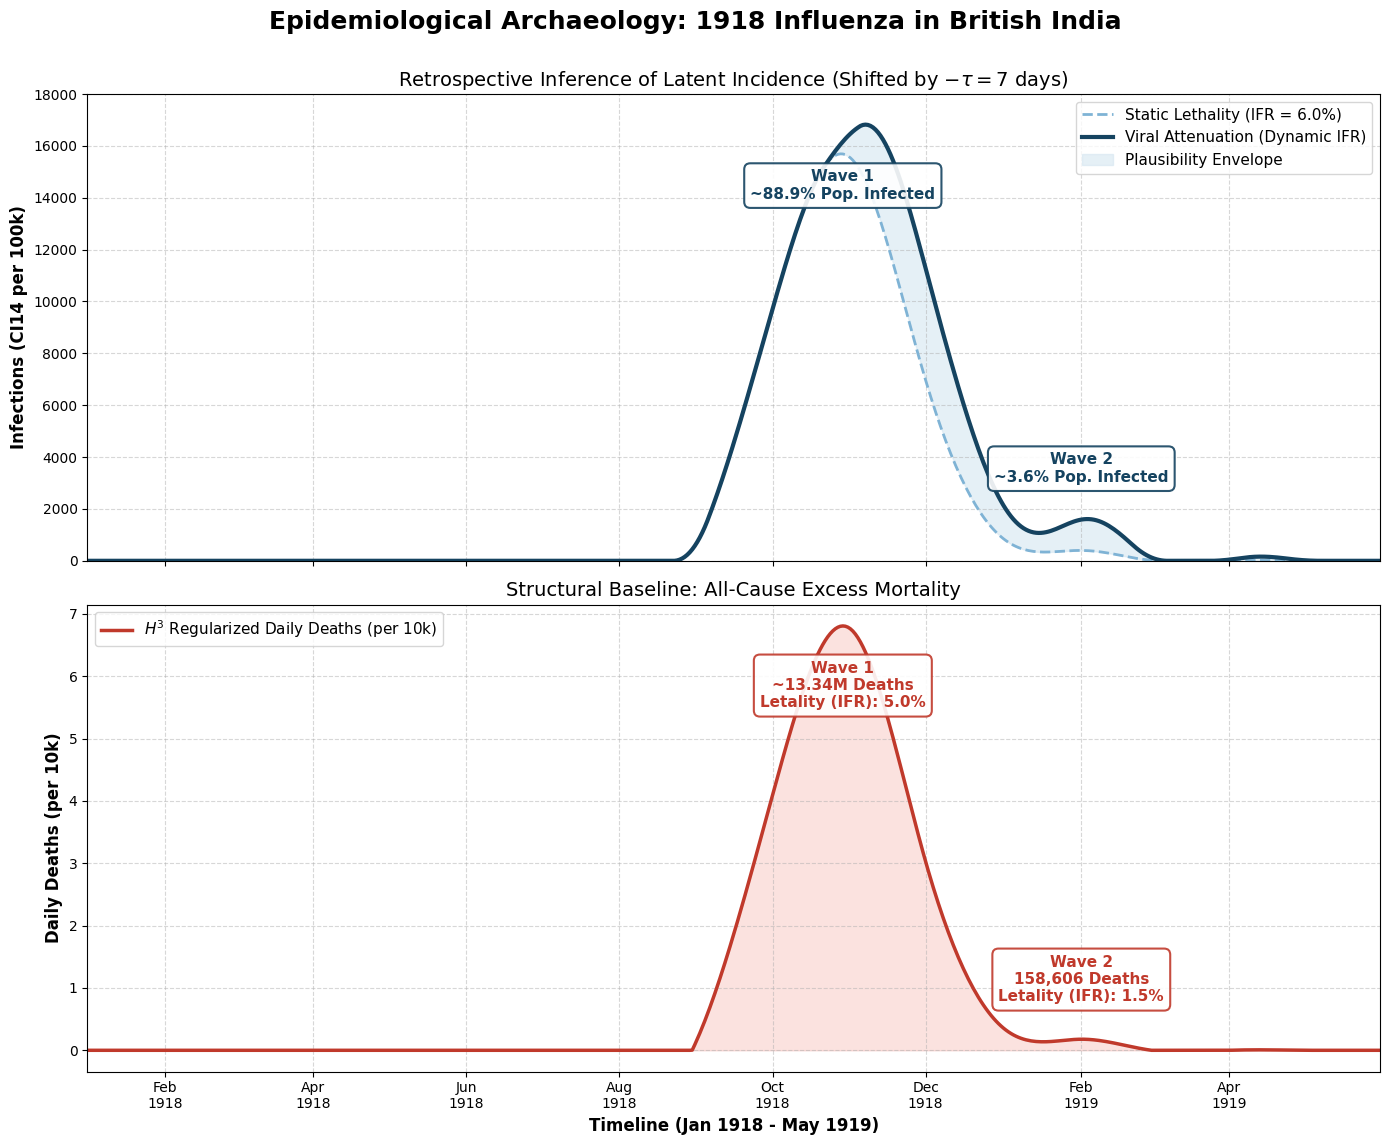

In [6]:
#BRITISH INDIA

TAU_SHIFT = 7                 
TOTAL_DEATHS = 13500000       
POPULATION = 300000000        

IFR_PEAK = 0.06               
IFR_ENDEMIC = 0.001           
K_DECAY = 0.015               

# =============================================================================
# 2. RAW HISTORICAL DATA & H3 INTERPOLATION
# =============================================================================
meses_india = pd.date_range(start="1918-08-01", end="1919-07-01", freq='MS')
muertes_mensuales = [0, 164634, 3786585, 6256098, 2798780, 329268, 164634, 0, 0, 0, 0, 0]

dias_numericos = (meses_india - meses_india.min()).days
cs = CubicSpline(dias_numericos, muertes_mensuales)

fechas_diarias_full = pd.date_range(start="1918-01-01", end="1919-05-31", freq='D')
dias_evaluacion_full = (fechas_diarias_full - meses_india.min()).days

valid_mask = (fechas_diarias_full >= meses_india.min()) & (fechas_diarias_full <= meses_india.max())
muertes_diarias_h3 = np.zeros(len(fechas_diarias_full))
muertes_diarias_h3[valid_mask] = np.maximum(cs(dias_evaluacion_full[valid_mask]) / 30.0, 0)

muertes_diarias_h3 = muertes_diarias_h3 * (TOTAL_DEATHS / np.sum(muertes_diarias_h3))
df_daily = pd.DataFrame({'Date': fechas_diarias_full, 'Deaths_H3': muertes_diarias_h3})

# DENSIDAD POR 10,000 HABITANTES
df_daily['Deaths_per_10k'] = df_daily['Deaths_H3'] * 10000 / POPULATION

# =============================================================================
# 3. DYNAMIC IFR & INFECTIONS
# =============================================================================
t_peak_idx = np.argmax(df_daily['Deaths_H3'])
t_array = np.arange(len(df_daily))

ifr_dynamic = np.where(
    t_array < t_peak_idx, 
    IFR_PEAK,  
    IFR_ENDEMIC + (IFR_PEAK - IFR_ENDEMIC) * np.exp(-K_DECAY * (t_array - t_peak_idx))
)

df_daily['Infection_Date'] = df_daily['Date'] - timedelta(days=TAU_SHIFT)
df_daily['Daily_Infections_Static'] = df_daily['Deaths_H3'] / IFR_PEAK
df_daily['Daily_Infections_Dynamic'] = df_daily['Deaths_H3'] / ifr_dynamic

factor_100k = POPULATION / 100000
df_infections = df_daily[['Infection_Date', 'Daily_Infections_Static', 'Daily_Infections_Dynamic']].dropna().set_index('Infection_Date')
df_infections['CI14_Inf_Static'] = df_infections['Daily_Infections_Static'].rolling(window=14, min_periods=1).sum() / factor_100k
df_infections['CI14_Inf_Dynamic'] = df_infections['Daily_Infections_Dynamic'].rolling(window=14, min_periods=1).sum() / factor_100k

df_plot = pd.merge(df_daily[['Date', 'Deaths_H3', 'Deaths_per_10k']], df_infections[['CI14_Inf_Static', 'CI14_Inf_Dynamic']], 
                   left_on='Date', right_index=True, how='left').fillna(0)

peaks_idx, _ = find_peaks(df_plot['Deaths_H3'], distance=40, height=5000)
valleys_idx, _ = find_peaks(-df_plot['Deaths_H3'])
boundaries = np.sort(np.concatenate(([0], valleys_idx, [len(df_plot)-1])))

# =============================================================================
# 4. VISUALIZATION
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Epidemiological Archaeology: 1918 Influenza in British India', fontsize=18, fontweight='bold', y=0.95)

color_static, color_dynamic, color_fill = '#7FB3D5', '#154360', '#D4E6F1'     
color_death, color_death_fill = '#C0392B', '#F5B7B1' 

# TOP PLOT (INFECTIONS)
ax1.plot(df_plot['Date'], df_plot['CI14_Inf_Static'], color=color_static, linewidth=2, linestyle='--', label=r'Static Lethality (IFR = 6.0%)')
ax1.plot(df_plot['Date'], df_plot['CI14_Inf_Dynamic'], color=color_dynamic, linewidth=3, label=r'Viral Attenuation (Dynamic IFR)')
ax1.fill_between(df_plot['Date'], df_plot['CI14_Inf_Static'], df_plot['CI14_Inf_Dynamic'], color=color_fill, alpha=0.6, label='Plausibility Envelope')

for i, p_idx in enumerate(peaks_idx):
    peak_date_inf, peak_val_inf = df_plot['Date'].iloc[p_idx], df_plot['CI14_Inf_Dynamic'].iloc[p_idx]
    start_idx, end_idx = boundaries[boundaries < p_idx].max(), boundaries[boundaries > p_idx].min()
    wave_infected = df_daily['Daily_Infections_Dynamic'].iloc[start_idx:end_idx].sum()
    
    y_offset, v_align = (-20, 'top') if peak_val_inf > 12000 else (25, 'bottom')
    ax1.annotate(f"Wave {i+1}\n~{(wave_infected/POPULATION)*100:.1f}% Pop. Infected", xy=(peak_date_inf, peak_val_inf), 
                 xytext=(0, y_offset), textcoords='offset points', ha='center', va=v_align, 
                 fontsize=11, fontweight='bold', color=color_dynamic, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=color_dynamic, lw=1.5, alpha=0.9))

ax1.set_title(r'Retrospective Inference of Latent Incidence (Shifted by $-\tau=7$ days)', fontsize=14)
ax1.set_ylabel('Infections (CI14 per 100k)', fontsize=12, fontweight='bold')
ax1.set_xlim([pd.Timestamp('1918-01-01'), pd.Timestamp('1919-05-31')])
ax1.set_ylim(0, 18000)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)

# BOTTOM PLOT (MORTALITY)
ax2.plot(df_plot['Date'], df_plot['Deaths_per_10k'], color=color_death, linewidth=2.5, label=r'$H^3$ Regularized Daily Deaths (per 10k)')
ax2.fill_between(df_plot['Date'], 0, df_plot['Deaths_per_10k'], color=color_death_fill, alpha=0.4)

max_death_10k = df_plot['Deaths_per_10k'].max()
for i, p_idx in enumerate(peaks_idx):
    peak_date_dead, peak_val_dead_10k = df_plot['Date'].iloc[p_idx], df_plot['Deaths_per_10k'].iloc[p_idx]
    start_idx, end_idx = boundaries[boundaries < p_idx].max(), boundaries[boundaries > p_idx].min()
    wave_dead = df_daily['Deaths_H3'].iloc[start_idx:end_idx].sum()
    wave_infected = df_daily['Daily_Infections_Dynamic'].iloc[start_idx:end_idx].sum()
    wave_ifr = (wave_dead / wave_infected) * 100 if wave_infected > 0 else 0
    dead_str = f"~{wave_dead/1e6:.2f}M Deaths" if wave_dead > 1e6 else f"{int(wave_dead):,} Deaths"
    
    y_offset, v_align = (-25, 'top') if peak_val_dead_10k > (max_death_10k * 0.7) else (25, 'bottom')
    ax2.annotate(f"Wave {i+1}\n{dead_str}\nLetality (IFR): {wave_ifr:.1f}%", xy=(peak_date_dead, peak_val_dead_10k), 
                 xytext=(0, y_offset), textcoords='offset points', ha='center', va=v_align, 
                 fontsize=11, fontweight='bold', color=color_death, bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=color_death, lw=1.5, alpha=0.9))

ax2.set_title('Structural Baseline: All-Cause Excess Mortality', fontsize=14)
ax2.set_ylabel('Daily Deaths (per 10k)', fontsize=12, fontweight='bold') 
ax2.set_xlabel('Timeline (Jan 1918 - May 1919)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) 
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

plt.tight_layout()
plt.subplots_adjust(top=0.88) 
plt.savefig("1918_India.png", dpi=300, bbox_inches='tight')
plt.show()